# 05b - Binary ML Models and Tuning

This notebook extends the multiclass ML workflow by reframing the task as binary classification:
**home win (`1`) vs. away not lose (`0`)**.
It serves both as an analysis notebook and as a methodology record for the thesis.

## 1. Imports and Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from src.data_builder import attach_fbref_match_metadata
from src.feature_documentation import build_feature_dictionary, summarize_feature_sets
from src.feature_selection import select_leakage_safe_features, filter_features_by_missingness, filter_features_by_correlation
from src.ml_modeling import get_model_space, score_predictions, build_class_metrics_table, run_static_feature_set_screening
from src.rolling_backtest import run_rolling_backtest, summarize_predictions, evaluate_by_matchday, fit_final_ml_model
from src.run_artifacts import save_run_artifacts, save_deployment_model

## 2. Load the Advanced Match Table and Attach Matchday Metadata

In [2]:
features_path = PROCESSED_DATA_DIR / 'match_features_advanced.parquet'
if not features_path.exists():
    features_path = PROCESSED_DATA_DIR / 'match_features_advanced.csv'

try:
    df = pd.read_parquet(features_path) if features_path.suffix == '.parquet' else pd.read_csv(features_path)
except Exception:
    df = pd.read_csv(PROCESSED_DATA_DIR / 'match_features_advanced.csv')

df['date'] = pd.to_datetime(df['date'], errors='coerce')

fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.parquet'
if not fbref_schedule_path.exists():
    fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.csv'
try:
    fbref_schedule = pd.read_parquet(fbref_schedule_path) if fbref_schedule_path.suffix == '.parquet' else pd.read_csv(fbref_schedule_path)
except Exception:
    fbref_schedule = pd.read_csv(RAW_DATA_DIR / 'fbref' / 'schedule.csv')
df = df.drop(columns=[col for col in ['round', 'week', 'matchday'] if col in df.columns], errors='ignore').copy()
df = attach_fbref_match_metadata(df, fbref_schedule)

print('Dataset shape:', df.shape)
print(f"FBref matchday merge coverage: {df['matchday'].notna().mean():.1%}")
display(df[['date', 'home_team', 'away_team', 'home_win', 'target_1x2', 'matchday']].head())

Dataset shape: (882, 252)
FBref matchday merge coverage: 85.1%


,date,home_team,away_team,home_win,target_1x2,matchday
0,2023-08-18 18:30:00,Werder Bremen,Bayern Munich,0,A,1
1,2023-08-19 13:30:00,Bayer Leverkusen,RasenBallsport Leipzig,1,H,1
2,2023-08-19 13:30:00,Wolfsburg,FC Heidenheim,1,H,1
3,2023-08-19 13:30:00,Hoffenheim,Freiburg,0,A,1
4,2023-08-19 13:30:00,Augsburg,Borussia M.Gladbach,0,D,1


## 3. Define the Binary Target

The target is `home_win`.
A value of `0` represents any away-not-lose outcome, i.e. either a draw or an away win.

In [3]:
TARGET_COL = 'home_win'
RUN_KEY = 'ml_binary'
TARGET_LABEL_MAP = {1: 'Home win', 0: 'Away not lose'}
print(df[TARGET_COL].value_counts(normalize=True).rename('share'))

home_win
0    0.579365
1    0.420635
Name: share, dtype: float64


## 4. Build the Leakage-Safe Candidate Feature Pool

In [4]:
candidate_features = select_leakage_safe_features(df)
df_pretest = df[df['season_id'] != 2025].copy()

features_after_missing = filter_features_by_missingness(df_pretest, candidate_features, max_missing_share=0.35)
features_after_corr, dropped_corr_features = filter_features_by_correlation(df_pretest, features_after_missing, threshold=0.95)

print('Candidate features:', len(candidate_features))
print('After missingness filter:', len(features_after_missing))
print('After correlation filter:', len(features_after_corr))
print('Dropped due to correlation:', len(dropped_corr_features))

Candidate features: 219
After missingness filter: 219
After correlation filter: 159
Dropped due to correlation: 60


## 5. Rank the Filtered Features and Define Feature Sets

In [5]:
X_rank = df_pretest[features_after_corr].copy()
y_rank = df_pretest[TARGET_COL].copy()
rf_selector = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
])
rf_selector.fit(X_rank, y_rank)
rf_importance = pd.DataFrame({'feature': features_after_corr, 'importance': rf_selector.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False).reset_index(drop=True)

top_20_features = rf_importance.head(20)['feature'].tolist()
top_35_features = rf_importance.head(35)['feature'].tolist()
compact_domain_features = [col for col in features_after_corr if ('elo' in col or 'rest_days' in col or 'expected_points' in col or 'np_xg' in col or 'ppda' in col or 'deep_completions' in col)]
compact_domain_features = list(dict.fromkeys(compact_domain_features))
feature_sets = {
    'full_filtered': features_after_corr,
    'top_20_rf': top_20_features,
    'top_35_rf': top_35_features,
    'compact_domain': compact_domain_features,
}
display(rf_importance.head(30))

,feature,importance
0,diff_deep_completions_cum_avg_before,0.025813
1,diff_np_xg_for_cum_avg_before,0.019616
2,home_xg_for_cum_avg_before,0.019257
3,home_expected_points_cum_avg_before,0.018844
4,diff_np_xg_for_avg_last_8_venue,0.017585
5,diff_expected_points_cum_avg_before,0.017187
6,diff_expected_points_avg_last_8_venue,0.014467
7,diff_expected_points_avg_last_8_overall,0.014238
8,diff_deep_completions_avg_last_8_overall,0.012461
9,home_expected_points_avg_last_8_overall,0.012362


## 6. Document the Feature Subsets

In [6]:
feature_set_summary = summarize_feature_sets(feature_sets)
feature_dictionary = build_feature_dictionary(sorted(set().union(*[set(features) for features in feature_sets.values()])))
display(feature_set_summary)
display(feature_dictionary.head(40))

,feature_set,n_features,families_present,family_counts_json,feature_list
0,top_20_rf,20,"Elo strength, Expected goals against, Expected...","{""Elo strength"": 1, ""Expected goals against"": ...","diff_deep_completions_cum_avg_before, diff_np_..."
1,top_35_rf,35,"Elo strength, Expected goals against, Expected...","{""Elo strength"": 2, ""Expected goals against"": ...","diff_deep_completions_cum_avg_before, diff_np_..."
2,compact_domain,73,"Elo strength, Expected goal difference, Expect...","{""Elo strength"": 3, ""Expected goal difference""...","home_elo_pre, away_elo_pre, elo_diff_pre, home..."
3,full_filtered,159,"Elo strength, Expected goal difference, Expect...","{""Elo strength"": 3, ""Expected goal difference""...","home_elo_pre, away_elo_pre, elo_diff_pre, home..."


,feature,side,family,scope,horizon,description
0,away_elo_pre,Away team,Elo strength,General pre-match feature,Single-value pre-match feature,Away team; Elo strength; General pre-match fea...
1,elo_diff_pre,Home minus away,Elo strength,Relative difference,Single-value pre-match feature,Home minus away; Elo strength; Relative differ...
2,home_elo_pre,Home team,Elo strength,General pre-match feature,Single-value pre-match feature,Home team; Elo strength; General pre-match fea...
3,diff_np_xg_diff_avg_last_2_overall,Home minus away,Expected goal difference,Relative difference,Short-term form (last 2),Home minus away; Expected goal difference; Rel...
4,diff_np_xg_diff_avg_last_2_venue,Home minus away,Expected goal difference,Relative difference,Short-term form (last 2),Home minus away; Expected goal difference; Rel...
5,away_xg_against_avg_last_2_overall,Away team,Expected goals against,All previous matches,Short-term form (last 2),Away team; Expected goals against; All previou...
6,away_xg_against_avg_last_2_venue,Away team,Expected goals against,Home/away venue split,Short-term form (last 2),Away team; Expected goals against; Home/away v...
7,away_xg_against_avg_last_8_overall,Away team,Expected goals against,All previous matches,Medium-term form (last 8),Away team; Expected goals against; All previou...
8,away_xg_against_avg_last_8_venue,Away team,Expected goals against,Home/away venue split,Medium-term form (last 8),Away team; Expected goals against; Home/away v...
9,away_xg_against_cum_avg_before,Away team,Expected goals against,Season-to-date average,Season-to-date form,Away team; Expected goals against; Season-to-d...


## 7. Define the Model Space and Backtest Configuration

The binary notebook uses the same fast model space as the multiclass notebook so that the workflow remains practical for repeated seasonal reruns.

In [7]:
model_space = get_model_space(random_state=42)
MODEL_RUN_ORDER = list(model_space.keys())
BACKTEST_CONFIG = {
    'test_season_id': 2025,
    'target_col': TARGET_COL,
    'validation_size': 18,
    'min_train_size': 100,
    'n_validation_windows': 4,
    'validation_step_size': 18,
    'primary_metric': 'accuracy',
    'max_missing_share': 0.35,
    'correlation_threshold': 0.95,
    'random_state': 42,
}
print('Models:', MODEL_RUN_ORDER)
BACKTEST_CONFIG

Models: ['logistic_regression', 'naive_bayes', 'knn', 'svm', 'decision_tree', 'random_forest', 'hist_gradient_boosting']


{'test_season_id': 2025,
 'target_col': 'home_win',
 'validation_size': 18,
 'min_train_size': 100,
 'n_validation_windows': 4,
 'validation_step_size': 18,
 'primary_metric': 'accuracy',
 'max_missing_share': 0.35,
 'correlation_threshold': 0.95,
 'random_state': 42}

## 8. Run Screening and Rolling Backtests

In [8]:
model_outputs = {}
screening_tables = []
feature_batch_tables = []

for model_name in MODEL_RUN_ORDER:
    print(f'Running {model_name}...')
    screening = run_static_feature_set_screening(
        df=df,
        feature_sets=feature_sets,
        model_name=model_name,
        model_spec=model_space[model_name],
        target_col=TARGET_COL,
        primary_metric=BACKTEST_CONFIG['primary_metric'],
    )
    best_feature_set = screening.iloc[0]['feature_set']
    selected_features = feature_sets[best_feature_set]
    predictions, tuning, feature_summary = run_rolling_backtest(
        df=df,
        candidate_features=selected_features,
        model_space={model_name: model_space[model_name]},
        **BACKTEST_CONFIG,
    )
    results = summarize_predictions(predictions)
    model_outputs[model_name] = {
        'screening': screening,
        'best_feature_set': best_feature_set,
        'selected_features': selected_features,
        'predictions': predictions,
        'tuning': tuning,
        'feature_summary': feature_summary,
        'results': results,
    }
    screening_tables.append(screening.assign(best_feature_set_selected=screening['feature_set'] == best_feature_set, model=model_name))
    feature_batch_tables.append(feature_summary.assign(model=model_name, feature_set=best_feature_set))

screening_summary = pd.concat(screening_tables, ignore_index=True)
all_predictions = pd.concat([payload['predictions'] for payload in model_outputs.values()], ignore_index=True)
all_tuning = pd.concat([payload['tuning'] for payload in model_outputs.values()], ignore_index=True)
all_feature_batches = pd.concat(feature_batch_tables, ignore_index=True)
all_model_results = pd.concat([payload['results'] for payload in model_outputs.values()], ignore_index=True).sort_values(['accuracy', 'macro_f1'], ascending=False).reset_index(drop=True)
screening_summary

Running logistic_regression...
Running naive_bayes...
Running knn...
Running svm...
Running decision_tree...
Running random_forest...
Running hist_gradient_boosting...


,model,feature_set,n_features,accuracy,macro_f1,weighted_f1,best_params,best_feature_set_selected
0,logistic_regression,top_35_rf,35,0.666667,0.638156,0.672012,{'model__C': 0.1},True
1,logistic_regression,top_20_rf,20,0.660819,0.635582,0.667549,{'model__C': 0.1},False
2,logistic_regression,full_filtered,159,0.643275,0.626731,0.652925,{'model__C': 0.1},False
3,logistic_regression,compact_domain,73,0.631579,0.614493,0.641546,{'model__C': 0.1},False
4,naive_bayes,top_20_rf,20,0.690058,0.661082,0.694115,{'model__var_smoothing': 1e-09},True
5,naive_bayes,top_35_rf,35,0.684211,0.653378,0.687838,{'model__var_smoothing': 1e-09},False
6,naive_bayes,compact_domain,73,0.666667,0.645267,0.674309,{'model__var_smoothing': 1e-09},False
7,naive_bayes,full_filtered,159,0.643275,0.620373,0.651454,{'model__var_smoothing': 1e-09},False
8,knn,compact_domain,73,0.736842,0.697011,0.733630,"{'model__n_neighbors': 5, 'model__weights': 'u...",True
9,knn,top_20_rf,20,0.730994,0.697368,0.730994,"{'model__n_neighbors': 5, 'model__weights': 'u...",False


## 9. Compare All Binary Model Results

In [9]:
all_model_results

,model,accuracy,macro_f1,weighted_f1
0,naive_bayes,0.700000,0.688900,0.695865
1,svm,0.696296,0.684597,0.691797
2,random_forest,0.670370,0.656100,0.664403
3,logistic_regression,0.659259,0.652373,0.658172
4,hist_gradient_boosting,0.655556,0.635723,0.645797
5,knn,0.629630,0.617542,0.625600
6,decision_tree,0.625926,0.612086,0.620770


## 10. Validation-vs-Test Diagnostic

In [10]:
optimization_diagnostics = (
    all_tuning.groupby('model')
    .agg(
        mean_validation_accuracy=('val_accuracy', 'mean'),
        std_validation_accuracy=('val_accuracy', 'std'),
        mean_validation_macro_f1=('val_macro_f1', 'mean'),
        n_unique_param_sets=('best_params', 'nunique'),
        n_batches=('batch_id', 'nunique'),
    )
    .reset_index()
    .merge(all_model_results[['model', 'accuracy', 'macro_f1']].rename(columns={'accuracy': 'test_accuracy', 'macro_f1': 'test_macro_f1'}), on='model', how='left')
)
optimization_diagnostics['validation_minus_test_accuracy'] = optimization_diagnostics['mean_validation_accuracy'] - optimization_diagnostics['test_accuracy']
optimization_diagnostics.sort_values(['validation_minus_test_accuracy', 'test_accuracy'], ascending=[False, False]).reset_index(drop=True)

,model,mean_validation_accuracy,std_validation_accuracy,mean_validation_macro_f1,n_unique_param_sets,n_batches,test_accuracy,test_macro_f1,validation_minus_test_accuracy
0,decision_tree,0.681741,0.067085,0.646294,11,164,0.625926,0.612086,0.055815
1,random_forest,0.715955,0.029040,0.691585,4,164,0.670370,0.656100,0.045585
2,knn,0.669631,0.038238,0.646851,4,164,0.629630,0.617542,0.040001
3,logistic_regression,0.683858,0.037460,0.663334,3,164,0.659259,0.652373,0.024599
4,hist_gradient_boosting,0.679031,0.040646,0.643462,2,164,0.655556,0.635723,0.023476
5,naive_bayes,0.718919,0.051759,0.698568,1,164,0.700000,0.688900,0.018919
6,svm,0.712737,0.037107,0.690248,3,164,0.696296,0.684597,0.016441


## 11. Accuracy by Bundesliga Matchday

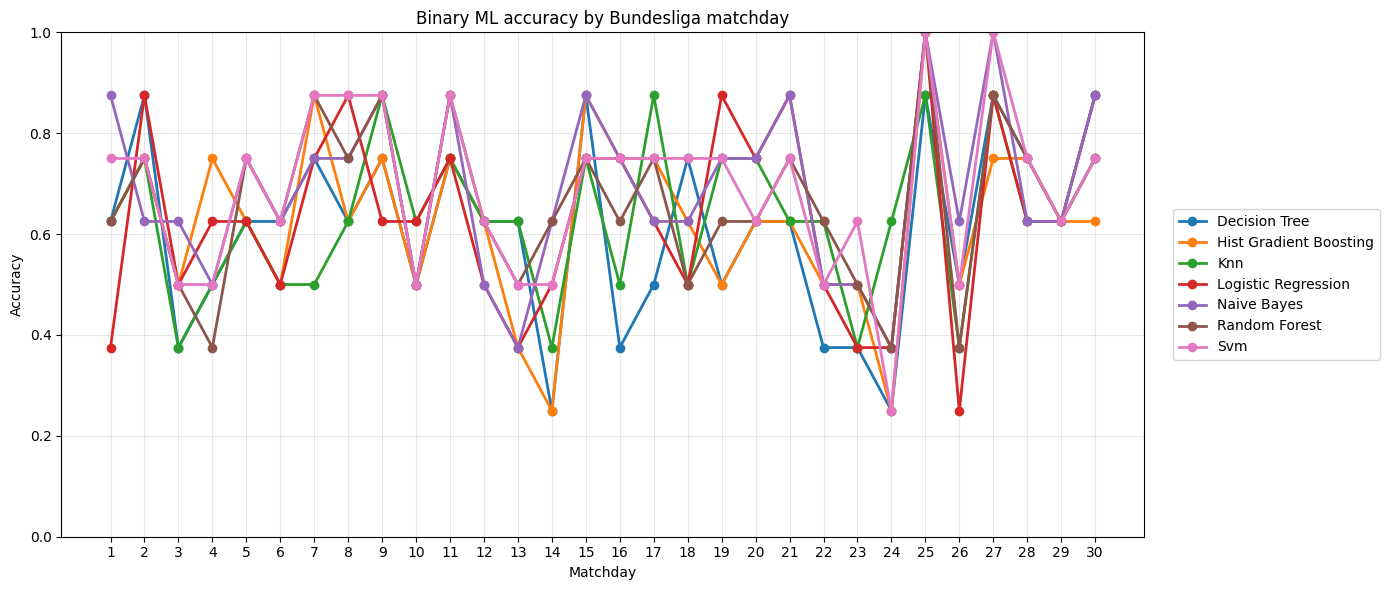

,model,matchday,n_matches,accuracy,macro_f1,weighted_f1
0,decision_tree,1,8,0.625,0.384615,0.480769
1,decision_tree,2,8,0.875,0.854545,0.868182
2,decision_tree,3,8,0.375,0.365079,0.365079
3,decision_tree,4,8,0.500,0.333333,0.416667
4,decision_tree,5,8,0.625,0.563636,0.645455
...,...,...,...,...,...,...
205,svm,26,8,0.500,0.500000,0.500000
206,svm,27,8,1.000,1.000000,1.000000
207,svm,28,8,0.750,0.666667,0.791667
208,svm,29,8,0.625,0.619048,0.619048


In [11]:
accuracy_by_matchday = evaluate_by_matchday(all_predictions)
fig, ax = plt.subplots(figsize=(14, 6))
for model_name, group in accuracy_by_matchday.groupby('model'):
    ax.plot(group['matchday'], group['accuracy'], marker='o', linewidth=2, label=model_name.replace('_', ' ').title())
ax.set_title('Binary ML accuracy by Bundesliga matchday')
ax.set_xlabel('Matchday')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(sorted(accuracy_by_matchday['matchday'].dropna().unique()))
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()
accuracy_by_matchday

## 12. Best-Model Diagnostics

In [12]:
best_model_name = all_model_results.iloc[0]['model']
best_payload = model_outputs[best_model_name]
best_predictions = best_payload['predictions'].copy()
best_tuning = best_payload['tuning'].copy()
best_feature_set = best_payload['best_feature_set']
best_selected_features = best_payload['selected_features']
best_metrics = score_predictions(best_predictions['target'], best_predictions['y_pred'])
best_class_metrics = build_class_metrics_table(best_metrics['classification_report_dict'])
best_class_metrics['class_name'] = best_class_metrics['class'].astype(int).map(TARGET_LABEL_MAP)

print('Best model:', best_model_name)
print('Best feature set:', best_feature_set)
display(all_model_results[all_model_results['model'] == best_model_name])
display(best_tuning[['val_accuracy', 'val_macro_f1', 'val_weighted_f1']].agg(['mean', 'std', 'min', 'max']).T)
display(best_class_metrics)

Best model: naive_bayes
Best feature set: top_20_rf


,model,accuracy,macro_f1,weighted_f1
0,naive_bayes,0.7,0.6889,0.695865


,mean,std,min,max
val_accuracy,0.718919,0.051759,0.638889,0.847222
val_macro_f1,0.698568,0.046646,0.622685,0.828433
val_weighted_f1,0.716381,0.052696,0.631758,0.846577


,class,precision,recall,f1_score,support,class_name
0,0,0.705882,0.794702,0.747664,151.0,Away not lose
1,1,0.690000,0.579832,0.630137,119.0,Home win


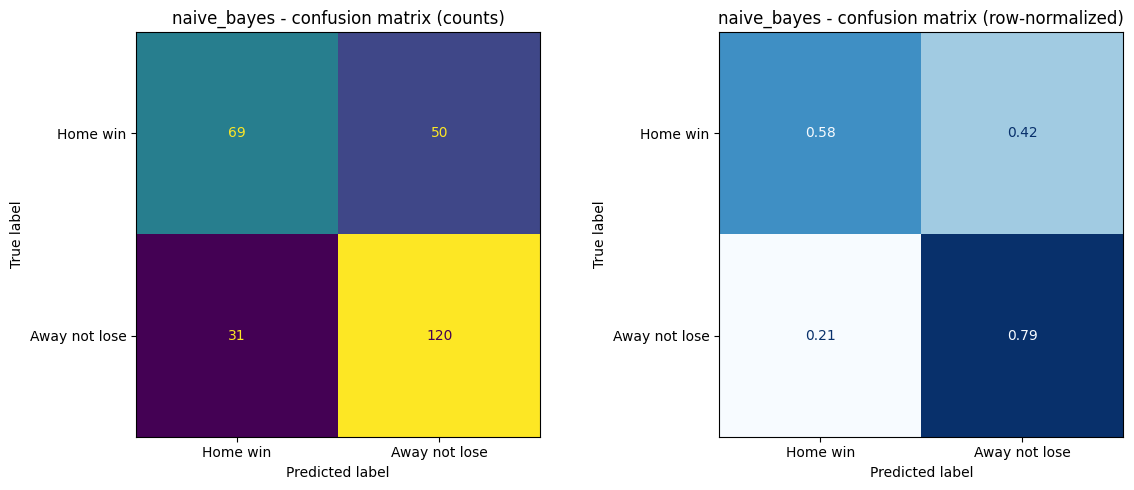

In [13]:
labels = [1, 0]
display_labels = [TARGET_LABEL_MAP[label] for label in labels]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=labels), display_labels=display_labels).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_model_name} - confusion matrix (counts)')
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=labels, normalize='true'), display_labels=display_labels).plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title(f'{best_model_name} - confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

## 13. Save Run Outputs and Persist the Deployment Model

In [15]:
final_fit = fit_final_ml_model(
    df=df,
    candidate_features=best_selected_features,
    model_name=best_model_name,
    model_spec=model_space[best_model_name],
    target_col=TARGET_COL,
    validation_size=BACKTEST_CONFIG['validation_size'],
    min_train_size=BACKTEST_CONFIG['min_train_size'],
    n_validation_windows=BACKTEST_CONFIG['n_validation_windows'],
    validation_step_size=BACKTEST_CONFIG['validation_step_size'],
    max_missing_share=BACKTEST_CONFIG['max_missing_share'],
    correlation_threshold=BACKTEST_CONFIG['correlation_threshold'],
    primary_metric=BACKTEST_CONFIG['primary_metric'],
)

run_metadata = {
    'run_key': RUN_KEY,
    'target_col': TARGET_COL,
    'task_type': 'binary_ml',
    'test_season_id': BACKTEST_CONFIG['test_season_id'],
    'model_order': MODEL_RUN_ORDER,
    'backtest_config': BACKTEST_CONFIG,
    'best_model_name': best_model_name,
    'best_feature_set': best_feature_set,
    'best_selected_features': best_selected_features,
    'deployment_fit_summary': final_fit['fit_summary'],
}

run_dir = save_run_artifacts(
    run_key=RUN_KEY,
    metadata=run_metadata,
    tables={
        'all_model_results': all_model_results,
        'all_predictions': all_predictions,
        'all_tuning': all_tuning,
        'all_feature_batches': all_feature_batches,
        'screening_summary': screening_summary,
        'feature_set_summary': feature_set_summary,
        'feature_dictionary': feature_dictionary,
        'optimization_diagnostics': optimization_diagnostics,
        'accuracy_by_matchday': accuracy_by_matchday,
        'best_model_predictions': best_predictions,
        'best_model_class_metrics': best_class_metrics,
    },
)

artifact_path = save_deployment_model(
    run_key=RUN_KEY,
    artifact_name='best_model',
    model_object={
        'estimator': final_fit['estimator'],
        'selected_features': final_fit['selected_features'],
        'target_col': TARGET_COL,
        'model_name': best_model_name,
        'feature_set_name': best_feature_set,
    },
    metadata={
        'run_key': RUN_KEY,
        'best_model_name': best_model_name,
        'best_feature_set': best_feature_set,
        'selected_features': final_fit['selected_features'],
        'fit_summary': final_fit['fit_summary'],
    },
)

print('Saved run outputs to:', run_dir)
print('Saved deployment artifact to:', artifact_path)

Saved run outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\model_runs\ml_binary
Saved deployment artifact to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\models\deployment\ml_binary\best_model.pkl
